In [1]:
JUPYTER_NAME = "2-lens-simulation-manual"

In [2]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from qiskit import transpile
from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer_encore.simulator import generate_aer_simulator
from qiskit_hamiltonian_simulation.time_independent.direct import (
    MomentumDomainEvolutionQuadratic,
    PositionDomainEvolutionQuadratic,
)
from qiskit_hamiltonian_simulation.time_independent.sample_based import (
    KineticEvolutionSampleBased,
    PotentialEvolutionSampleBased,
)
from qiskit_phase_propagator.sample_based_manual import (
    phase_propagate_state_with_arbitrary_signal,
)

# from qiskit_phase_propagator.sample_based import (
#     QuadraticSignalSampleBasedPhasePropagator,
# )
from qiskit_signals.helper_types import EncodingType
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    MomentumAxis,
    PositionAxis,
)
from qiskit_signals.quantum_signal import GenericQuantumSignal, QuadraticQuantumSignal
from qiskit_signals.sample_based_signal import ArbitrarySignalForSampleBasedProtocol
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.big_matrix_version import big_matrix_circ
from wave_optics_propagation.elements import (
    free_space_signal_generator,
    radius_of_convex_planar_lens_as_a_func_of_z,
    thin_lens_signal_generator,
    thin_transparent_plate_signal_generator,
)
from wave_optics_propagation.storage import save_circuit, save_results
from wave_optics_propagation.visualization import plot_wavefunction

In [3]:
AerSimulator().available_devices()

('CPU', 'GPU')

In [4]:
AerSimulator().available_methods()

('automatic',
 'statevector',
 'density_matrix',
 'stabilizer',
 'matrix_product_state',
 'extended_stabilizer',
 'unitary',
 'superop',
 'tensor_network')

In [5]:
experiment_datetime = datetime.now()

---


### Initial parameters


In [ ]:
# beam parameters
vacuum_wavelength = 1e-6  # 1 micron
beam_FWHM = 5e-3  # 5 mm

# lens parameters
focal_length = 200e-3  # 200 mm
lens_diameter = 25e-3  # 25 mm
refractive_index = 1.5
lens_thickness = 1e-3  # 1 mm

# free space propagation parameters
propagation_after_lens = 1.5 * focal_length  # 1.5 times focal length

# simulation parameters
transverse_length = 10e-2  # 10 cm, transverse simulation window
num_of_steps_after_lens = 5
lens_slices = 10000
num_qubits = 6
max_delta = 0.1

### Constants


In [7]:
c = constants.c
# hbar = constants.hbar

### Derived parameters


In [8]:
k_0 = 2 * constants.pi / vacuum_wavelength
reduced_wavelength = vacuum_wavelength / refractive_index

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / np.sqrt(2 * np.log(2))
# gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

# vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength


### Derived objects


In [9]:
lens_slice_thickness = lens_thickness / lens_slices
lens_slice_positions = (
    np.linspace(0, lens_thickness, lens_slices, endpoint=False)
    + lens_slice_thickness / 2
)  # choosing the midpoint in each transverse slice

step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

lens_transverse_lengths = [
    radius_of_convex_planar_lens_as_a_func_of_z(focal_length, z, lens_thickness)
    for z in lens_slice_positions
]
print(lens_slice_positions)
print(lens_transverse_lengths)

[5.0000e-08 1.5000e-07 2.5000e-07 ... 9.9975e-04 9.9985e-04 9.9995e-04]
[np.float64(0.004472136711988478), np.float64(0.0077459665945750445), np.float64(0.009999999873689375), np.float64(0.011832159416746485), np.float64(0.013416407695535253), np.float64(0.014832397032114876), np.float64(0.016124515518545206), np.float64(0.017320508066951158), np.float64(0.018439088878977595), np.float64(0.01949358844339319), np.float64(0.020493901628089825), np.float64(0.02144761065786438), np.float64(0.022360679655254113), np.float64(0.023237899940278816), np.float64(0.024083189155506023), np.float64(0.024899799173676036), np.float64(0.025690465116048656), np.float64(0.026457513051464755), np.float64(0.027202940941338363), np.float64(0.02792848012555312), np.float64(0.028635642145985317), np.float64(0.029325756474922995), np.float64(0.02999999986360005), np.float64(0.030659419283566313), np.float64(0.031304951638215166), np.float64(0.03193743878366744), np.float64(0.03255764111618071), np.float64(0.0

### Approximations checks


In [10]:
assert (
    gaussian_beam_waist > 10 * vacuum_wavelength
)  # ensure paraxial approximation validity

### Axes


In [11]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)
# p_axis = MomentumAxis.from_position_axis(x_axis, hbar=hbar)

### Initial beam profile


(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

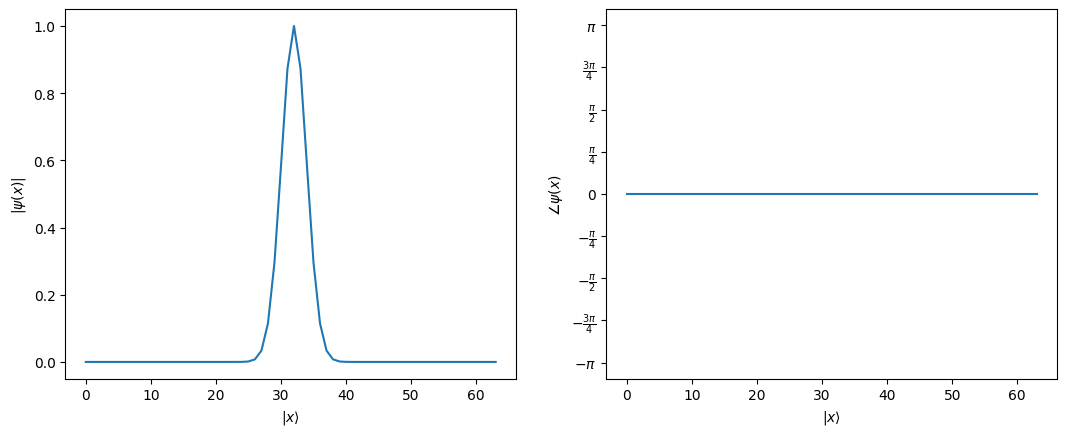

In [12]:
# def psi_signal_function(x):
#     norm_factor = 1 / (gaussian_sigma * (2 * constants.pi) ** 0.25)
#     return norm_factor * np.exp(-(((x - gaussian_mean) / gaussian_beam_waist) ** 2))


# def psi_signal_function(x):
#     return np.where(
#         (x > 1 / 3) & (x < 2 / 3),
#         1,
#         0,
#     )


# def psi_signal_function(x):
#     signal = np.zeros(dimension)
#     middle = dimension // 2
#     signal[middle - 20 : middle - 15] = 1
#     signal[middle + 15 : middle + 20] = 1
#     return signal

# psi_flat = Statevector.from_label("+" * num_qubits)

# psi = GenericQuantumSignal(x_axis, psi_signal_function)

psi = gaussian_signal(x_axis, gaussian_beam_waist, gaussian_mean)

# print(np.linalg.norm(psi.data) ** 2)
plot_wavefunction(psi.data, normalize=False)

### Lens potentials


In [13]:
lens_signals = [
    thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_length,
        wavelength=vacuum_wavelength,
        scale_down=True,
    )
    for lens_length in lens_transverse_lengths
]

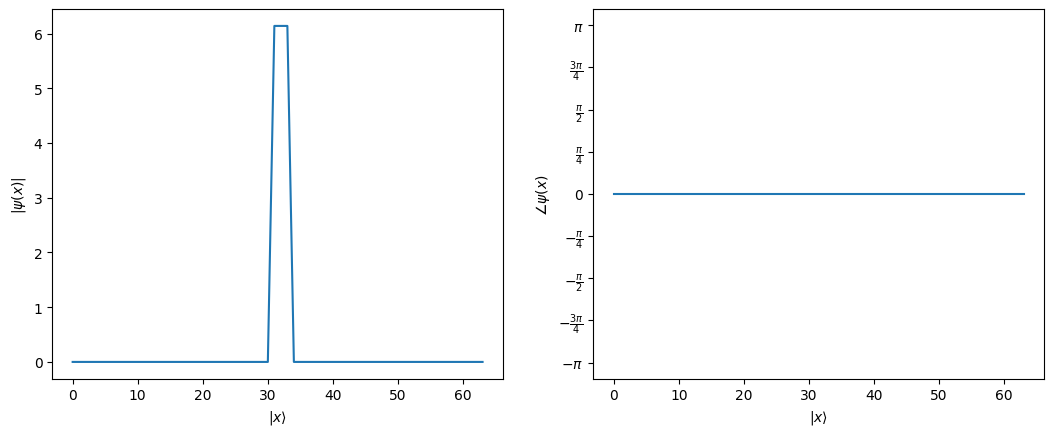

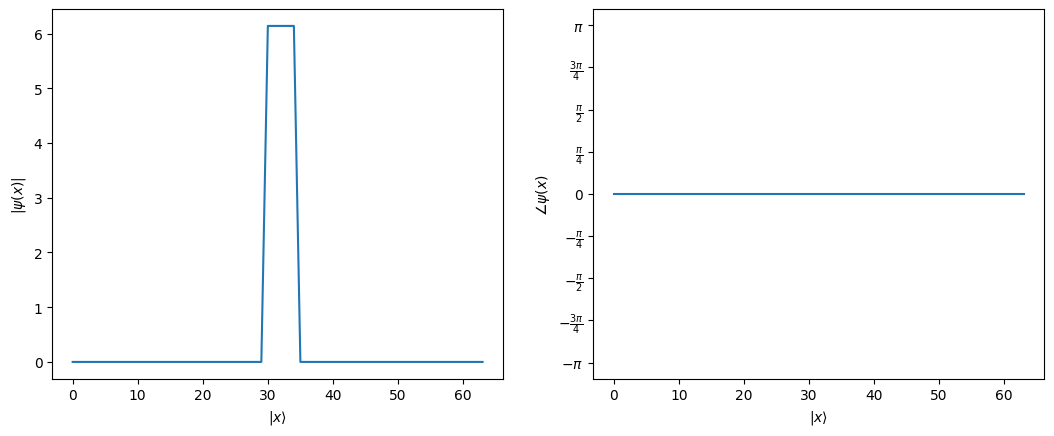

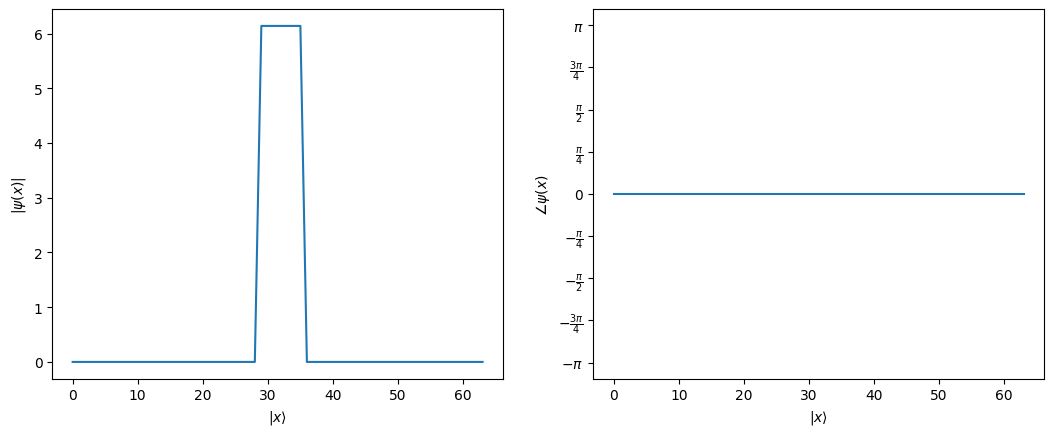

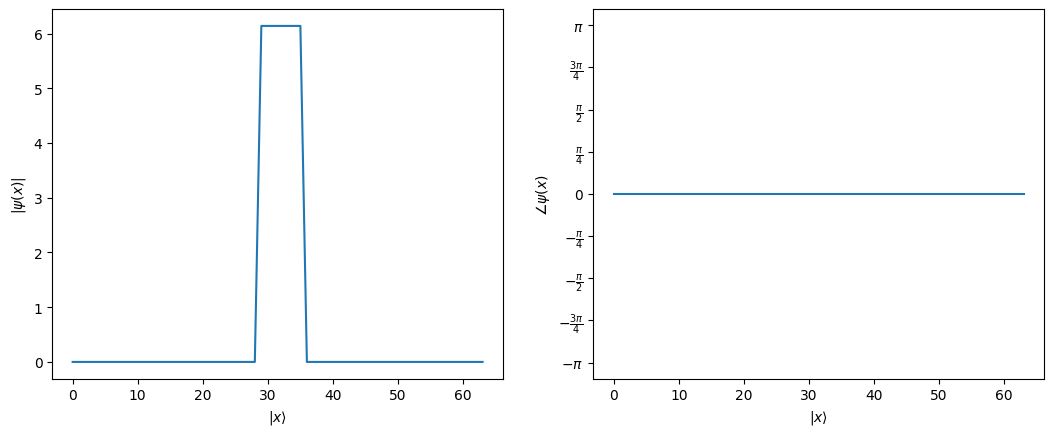

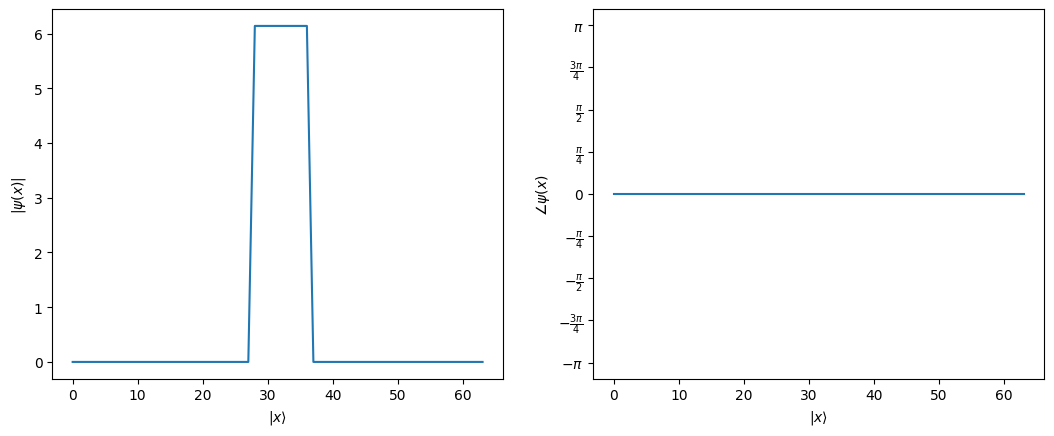

In [14]:
NUM_OF_PROFILES_TO_PLOT = 5

for i in range(NUM_OF_PROFILES_TO_PLOT):
    plot_wavefunction(lens_signals[i].data, normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

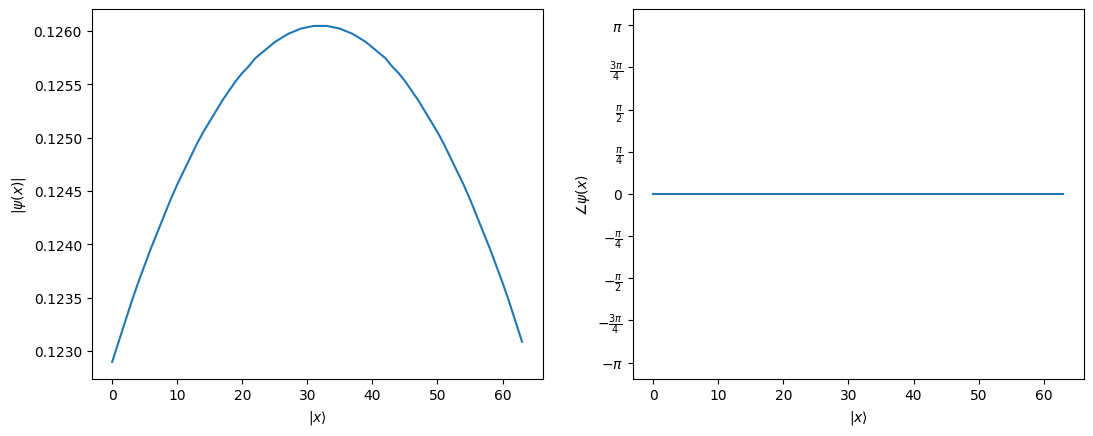

In [15]:
sum_signal = np.zeros_like(lens_signals[0].data)
for signal in lens_signals:
    sum_signal += signal.data

plot_wavefunction(sum_signal)

---


In [ ]:
current_state = Statevector(psi.data / np.linalg.norm(psi.data))
snapshots = dict([])

snapshots[f"step_{0}"] = current_state

inside_lens_propagation_remained = lens_thickness
total_lenses_simulated = 0
### Lens
for i, lens_length in enumerate(lens_transverse_lengths):
    print(f"Doing lens slice {i + 1}/{lens_slices}")

    lens_signal = lens_signals[i]
    sample_based_lens_signal = (
        ArbitrarySignalForSampleBasedProtocol.from_generic_signal(lens_signal)
    )

    if not np.isclose(np.std(sample_based_lens_signal.data), 0):
        print(f"max value in signal: {np.max(np.abs(sample_based_lens_signal.data))}")
        print(
            f"sum of amplitude square: {np.sum(np.abs(sample_based_lens_signal.data) ** 2)}"
        )
        # continue
        current_state = phase_propagate_state_with_arbitrary_signal(
            current_state, sample_based_lens_signal, max_delta
        )
        total_lenses_simulated += 1

    else:
        print("Skipped the lens slice because it is a flat phase.")
        break

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=lens_slice_thickness / c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    current_state = current_state.evolve(propagator)
    inside_lens_propagation_remained -= lens_slice_thickness

    snapshots[f"step_lens_{i}"] = current_state

# remaining propagation once the lens slice grows larger than the simulation window
while inside_lens_propagation_remained > 0:
    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=inside_lens_propagation_remained / c,
        wavelength=reduced_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    current_state = current_state.evolve(propagator)
    inside_lens_propagation_remained -= inside_lens_propagation_remained

snapshots["after_lens"] = current_state

for i in range(num_of_steps_after_lens):
    print(f"Doing free space step {i + 1}/{num_of_steps_after_lens}")

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=step_size_after_lens / c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    current_state = current_state.evolve(propagator)
    snapshots[f"step_after_lens_{i + 1}"] = current_state

snapshots["final"] = current_state

Doing lens slice 1/10000
6.138672045114456
113.04988343240908
direct de-initializer
Doing lens slice 2/10000
6.138672045114456
188.41647238734845
direct de-initializer
Doing lens slice 3/10000
6.138672045114456
263.78306134228785
direct de-initializer
Doing lens slice 4/10000
6.138672045114456
263.78306134228785
direct de-initializer
Doing lens slice 5/10000
6.138672045114456
339.14965029722725
direct de-initializer
Doing lens slice 6/10000
6.138672045114456
339.14965029722725
direct de-initializer
Doing lens slice 7/10000
6.138672045114456
414.5162392521666
direct de-initializer
Doing lens slice 8/10000
6.138672045114456
414.5162392521666
direct de-initializer
Doing lens slice 9/10000
6.138672045114456
414.5162392521666
direct de-initializer
Doing lens slice 10/10000
6.138672045114456
489.882828207106
direct de-initializer
Doing lens slice 11/10000
6.138672045114456
489.882828207106
direct de-initializer
Doing lens slice 12/10000
6.138672045114456
489.882828207106
direct de-initialize

In [ ]:
# save_results(result, "raw_result", experiment_datetime, wrapper_folder=JUPYTER_NAME)

In [ ]:
data = snapshots

In [ ]:
# def process_statevector(statevector):
#     return statevector
def process_statevector(statevector):
    """Process the statevector to extract position probabilities."""
    # n = statevector.num_qubits
    # rho = partial_trace(statevector, np.arange(int(n // 2), n).tolist())
    # reduced_state = rho.to_statevector()

    # return reduced_state
    return statevector


initial_statevector = process_statevector(data[f"step_{0}"])

lens_statevectors = [
    process_statevector(data[f"step_lens_{i}"]) if f"step_lens_{i}" in data else None
    for i in range(lens_slices)
]
after_lens_statevectors = [
    process_statevector(data[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in data
    else None
    for i in range(num_of_steps_after_lens)
]

Plotting initial state


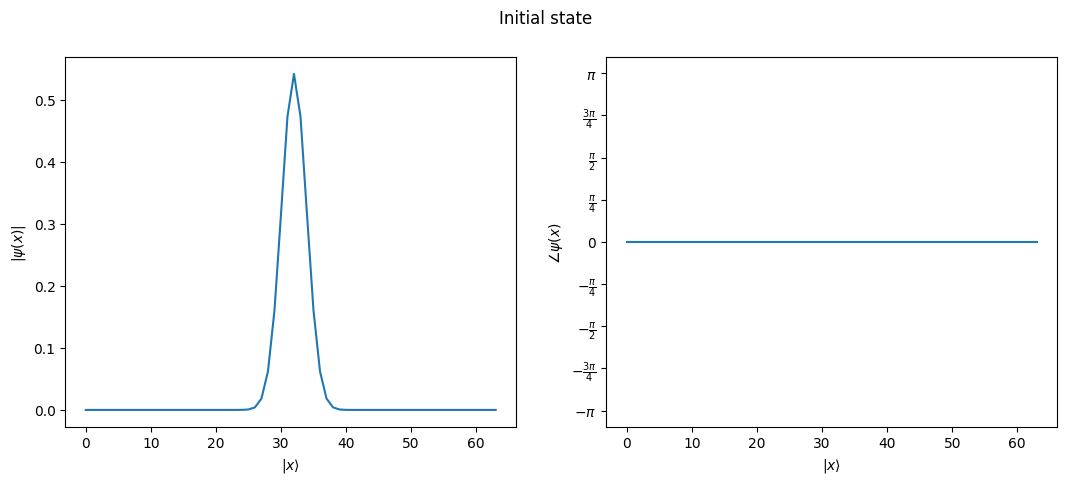

Plotting lens slice 1/1000


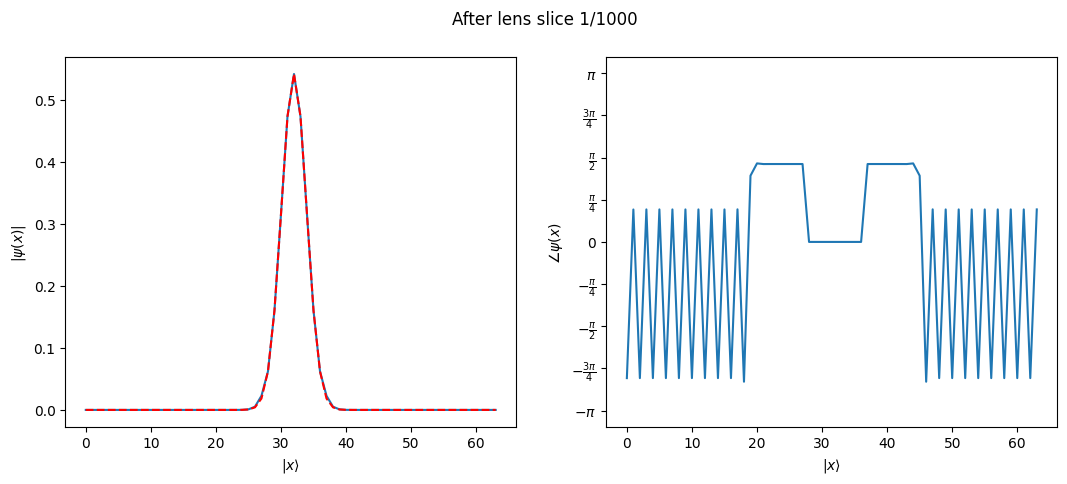

Plotting lens slice 6/1000


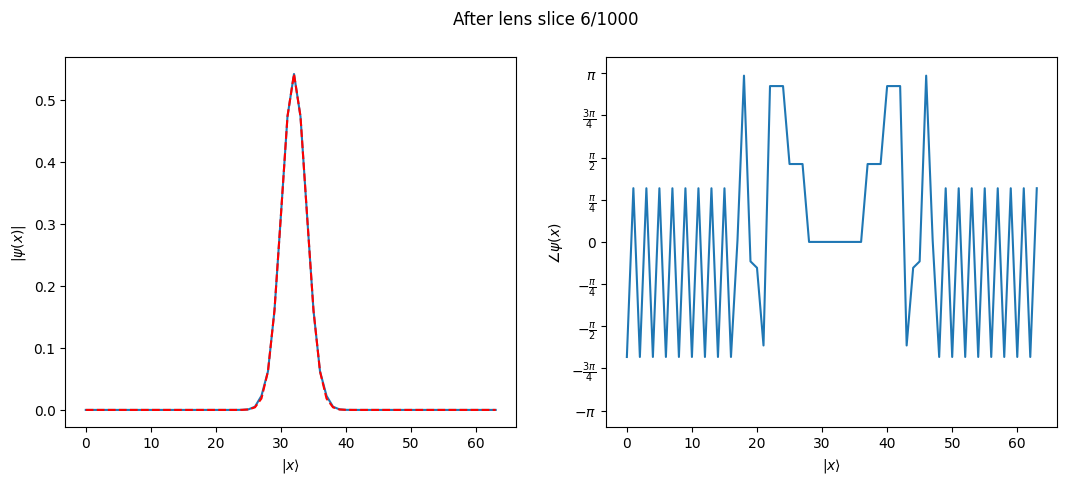

Plotting lens slice 11/1000


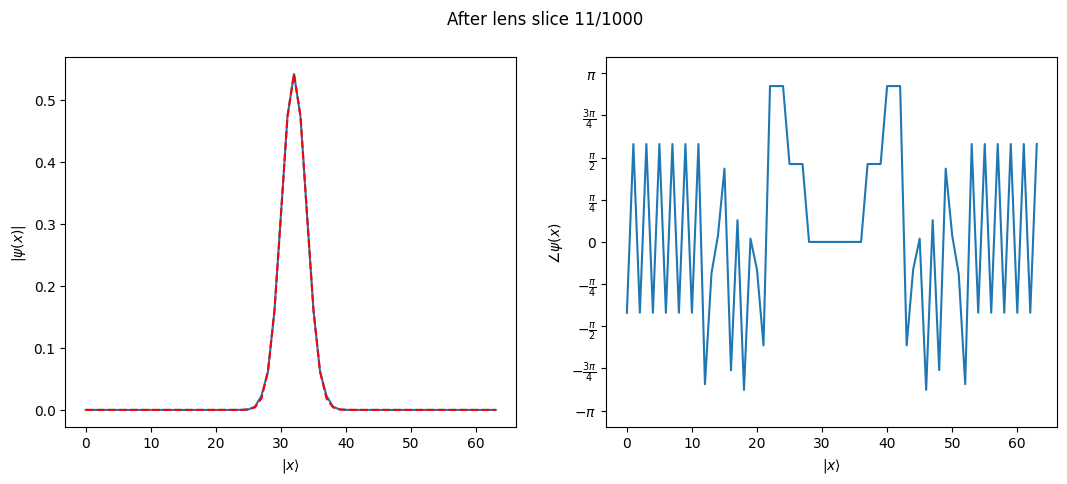

Plotting lens slice 16/1000


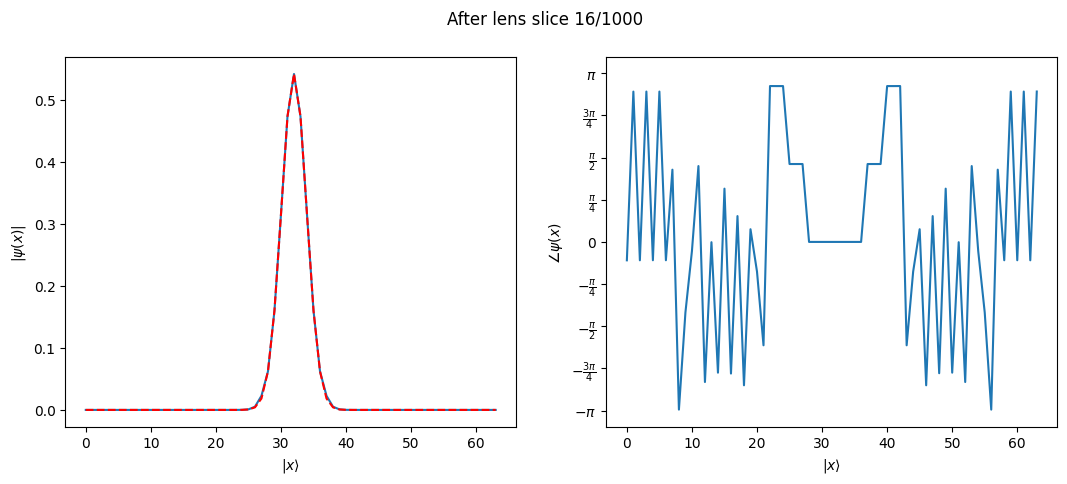

Plotting lens slice 21/1000


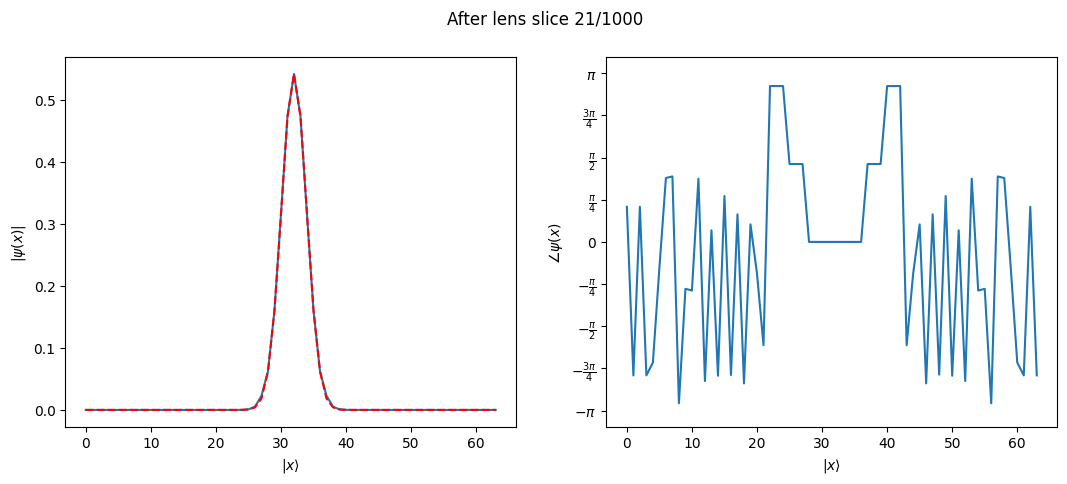

Plotting free space step 1/5


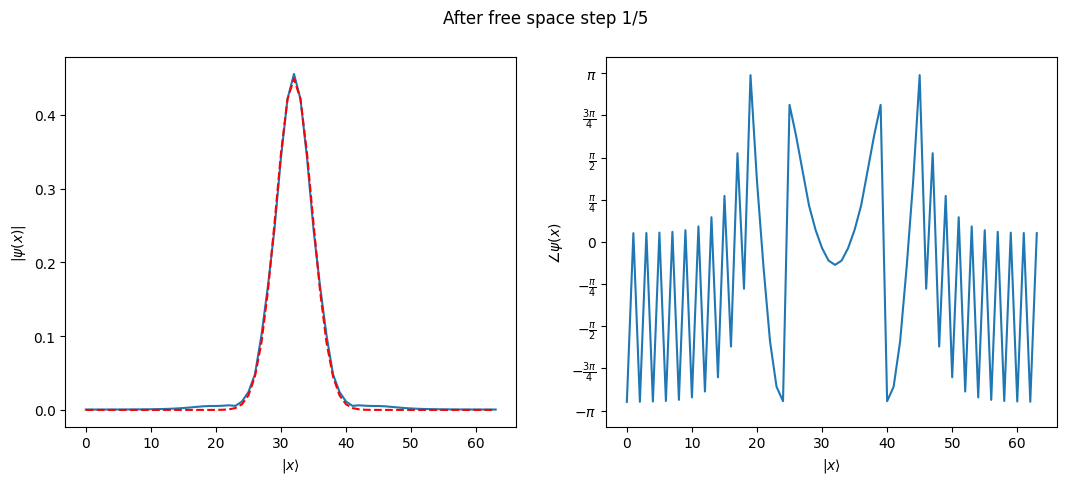

Plotting free space step 2/5


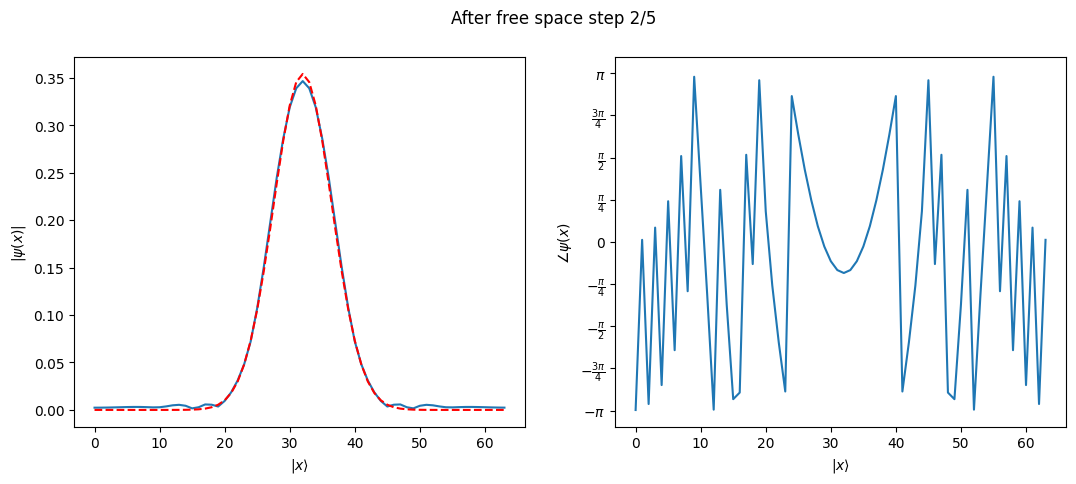

Plotting free space step 3/5


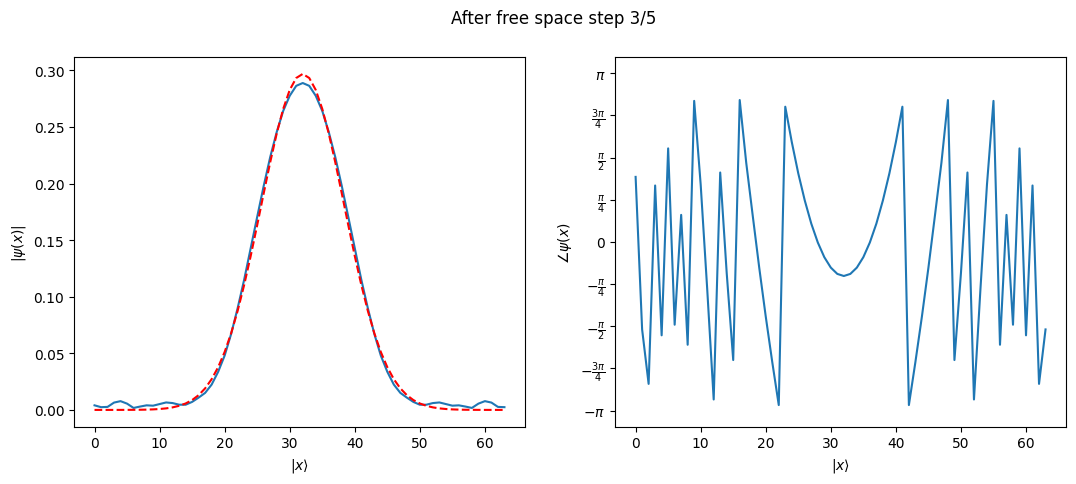

Plotting free space step 4/5


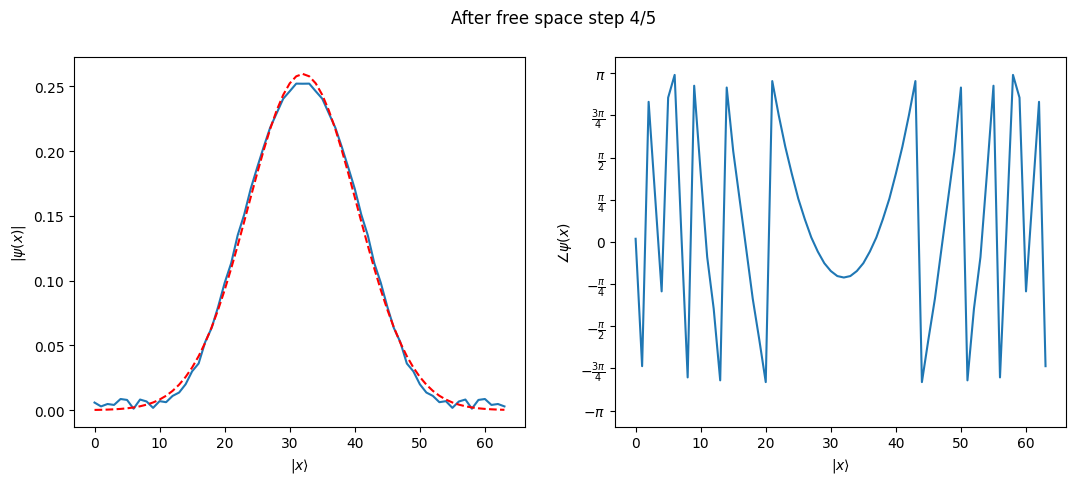

Plotting free space step 5/5


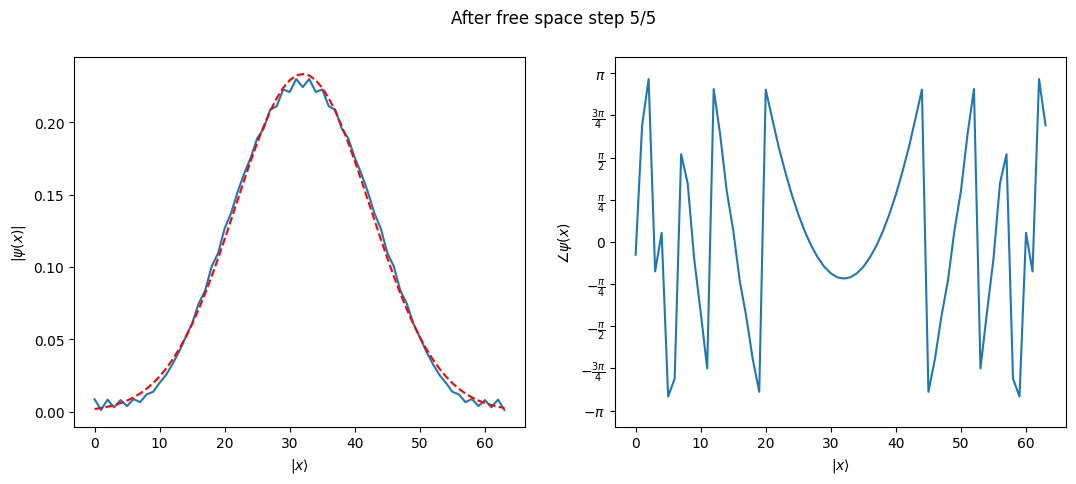

In [ ]:
print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

NUM_OF_LENS_SLICES_TO_PLOT = 5
NUM_OF_AFTER_LENS_SLICES_TO_PLOT = 5

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    if (
        total_lenses_simulated > NUM_OF_LENS_SLICES_TO_PLOT
        and i % (total_lenses_simulated // NUM_OF_LENS_SLICES_TO_PLOT) != 0
    ):
        continue

    print(f"Plotting lens slice {i + 1}/{lens_slices}")

    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = lens_slice_thickness * (i + 1)
    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist, z, focal_length, vacuum_wavelength, refractive_index
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    plt.suptitle(f"After lens slice {i + 1}/{lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    if i % (num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
        continue

    print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = step_size_after_lens * (i + 1) + lens_thickness
    R_z, w_z = free_space_propagated_gaussian_wavefront(
        gaussian_beam_waist, z, vacuum_wavelength, refractive_index=1.0
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    plt.suptitle(f"After free space step {i + 1}/{num_of_steps_after_lens}")
    plt.show()

In [ ]:
# final_state = process_statevector(result.get_statevector())

In [ ]:
# plot_wavefunction(final_state, plot_size_scale=1, normalize=True)